# ICCD PNG OCR — fixed lines to one JSON file

This notebook reads PNG UUIDs from `png-manifest.json`, reconstructs the OCR lines in vertical order, and exports one JSON array. The fixed layout is interpreted as:

- OCR row `2` → `titolo`
- OCR row `4` → `indirizzo`
- OCR row `5` → `secolo`
- PNG filename without `.png` → `id`

Rows `0`, `1`, `3`, and `6` are deliberately ignored.

## 1. Install dependencies

Run this in Google Colab or Ubuntu. If Tesseract is already installed, you can skip the first command.

In [1]:
!apt-get -qq update && apt-get -qq install -y tesseract-ocr tesseract-ocr-ita > /dev/null
%pip install -q pytesseract opencv-python-headless pandas matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


## 2. Configuration

In [2]:
from pathlib import Path
import json
import re
import shutil

import cv2
import pandas as pd
import pytesseract
from pytesseract import Output
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Change these paths to match your folders.
PNG_DIR = Path('1.output_png_schede/')
MANIFEST_PATH = Path('../1.online3Dmap/png-manifest.json')
OUTPUT_PATH = Path('./iccd_dati.json')

OCR_LANGUAGE = 'ita+eng'
OCR_CONFIG = '--oem 3 --psm 6'

# Crop containing the text block in the supplied 1448×2048 layout.
CROP_TOP = 0.42
CROP_BOTTOM = 0.72
MIN_WORD_CONFIDENCE = 20

assert shutil.which('tesseract'), 'Tesseract is not installed or is not on PATH.'
print('Tesseract:', pytesseract.get_tesseract_version())

Tesseract: 5.3.4


## 3. Load the manifest and locate the PNGs

In [3]:
with MANIFEST_PATH.open(encoding='utf-8') as file:
    manifest = json.load(file)

# Accept either a plain list or a dictionary containing a list.
if isinstance(manifest, dict):
    manifest = next(value for value in manifest.values() if isinstance(value, list))

manifest_ids = [str(value).strip() for value in manifest]

def resolve_png(item_id):
    expected = PNG_DIR / f'{item_id}.png'
    if expected.exists():
        return expected

    # Permit .PNG or another image extension when the stem is identical.
    matches = sorted(PNG_DIR.glob(f'{item_id}.*'))
    return matches[0] if matches else None

items = pd.DataFrame({'manifest_id': manifest_ids})
items['path'] = items['manifest_id'].map(resolve_png)

print(f'Manifest entries: {len(items)}')
print(f'PNGs found:      {items.path.notna().sum()}')
print(f'PNGs missing:    {items.path.isna().sum()}')
display(items[items.path.isna()].head(20))

assert items.path.notna().any(), 'No PNG files were found. Check PNG_DIR.'

Manifest entries: 438
PNGs found:      438
PNGs missing:    0


,manifest_id,path


## 4. Preprocess each PNG and reconstruct its OCR lines

In [4]:
def preprocess(path):
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError(f'Cannot read image: {path}')

    height, width = image.shape[:2]
    crop_y0 = int(height * CROP_TOP)
    crop_y1 = int(height * CROP_BOTTOM)
    crop = image[crop_y0:crop_y1, :]

    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(
        gray, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC
    )
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    binary = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]

    return image, binary, crop_y0


def ocr_lines(path):
    image, processed, crop_y0 = preprocess(path)

    words = pytesseract.image_to_data(
        processed,
        lang=OCR_LANGUAGE,
        config=OCR_CONFIG,
        output_type=Output.DATAFRAME,
    ).dropna(subset=['text'])

    words['text'] = words['text'].astype(str).str.strip()
    words = words[
        (words['text'] != '') &
        (words['conf'] >= MIN_WORD_CONFIDENCE)
    ].copy()

    if words.empty:
        return [], image

    reconstructed = []
    group_columns = ['block_num', 'par_num', 'line_num']

    for _, line_words in words.groupby(group_columns, sort=False):
        line_words = line_words.sort_values('left')
        text = ' '.join(line_words['text']).strip()

        x = int(line_words['left'].min() / 1.5)
        y = int(line_words['top'].min() / 1.5 + crop_y0)
        right = int(
            (line_words['left'] + line_words['width']).max() / 1.5
        )
        bottom = int(
            (line_words['top'] + line_words['height']).max() / 1.5 + crop_y0
        )

        reconstructed.append({
            'line_text': text,
            'confidence': round(float(line_words['conf'].mean()), 1),
            'x': x,
            'y': y,
            'width': right - x,
            'height': bottom - y,
        })

    # These positions become row indexes 0, 1, 2, 3, ...
    reconstructed.sort(key=lambda row: (row['y'], row['x']))
    return reconstructed, image

## 5. Extract the four fields using the fixed OCR rows

In [10]:
def clean_line(value):
    return re.sub(
        r"\s+",
        " ",
        str(value)
    ).strip(" |")


def parse_fields(lines, image_path):
    texts = [
        clean_line(
            line.get("line_text", "")
        )
        for line in lines
    ]

    line_count = len(texts)

    def get_row(index):
        if index < line_count and texts[index]:
            return texts[index]

        return None

    if line_count == 7:
        title_index = 2
        address_index = 4
        century_index = 5

    elif line_count == 6:
        title_index = 2
        address_index = 3
        century_index = 4

    elif line_count == 5:
        title_index = 2
        address_index = 3
        century_index = None

    else:
        title_index = None
        address_index = None
        century_index = None

    return {
        "id": Path(image_path).stem,
        "titolo": (
            get_row(title_index)
            if title_index is not None
            else None
        ),
        "indirizzo": (
            get_row(address_index)
            if address_index is not None
            else None
        ),
        "secolo": (
            get_row(century_index)
            if century_index is not None
            else None
        ),
        "linee_rilevate": line_count,
    }


sample_result = parse_fields(
    sample_lines,
    sample_path
)

display(
    pd.DataFrame([sample_result])
)

,id,titolo,indirizzo,secolo,linee_rilevate
0,0092caaa-f4cc-4c17-8bc5-e20cbe059637,Casa Ponte di Ferro,"Umbria, Gubbio (PG); Strada Ponte di Ferro, snc","XIX-XX, ultimo quarto",7


## 6. Optional visual check of the selected OCR rows

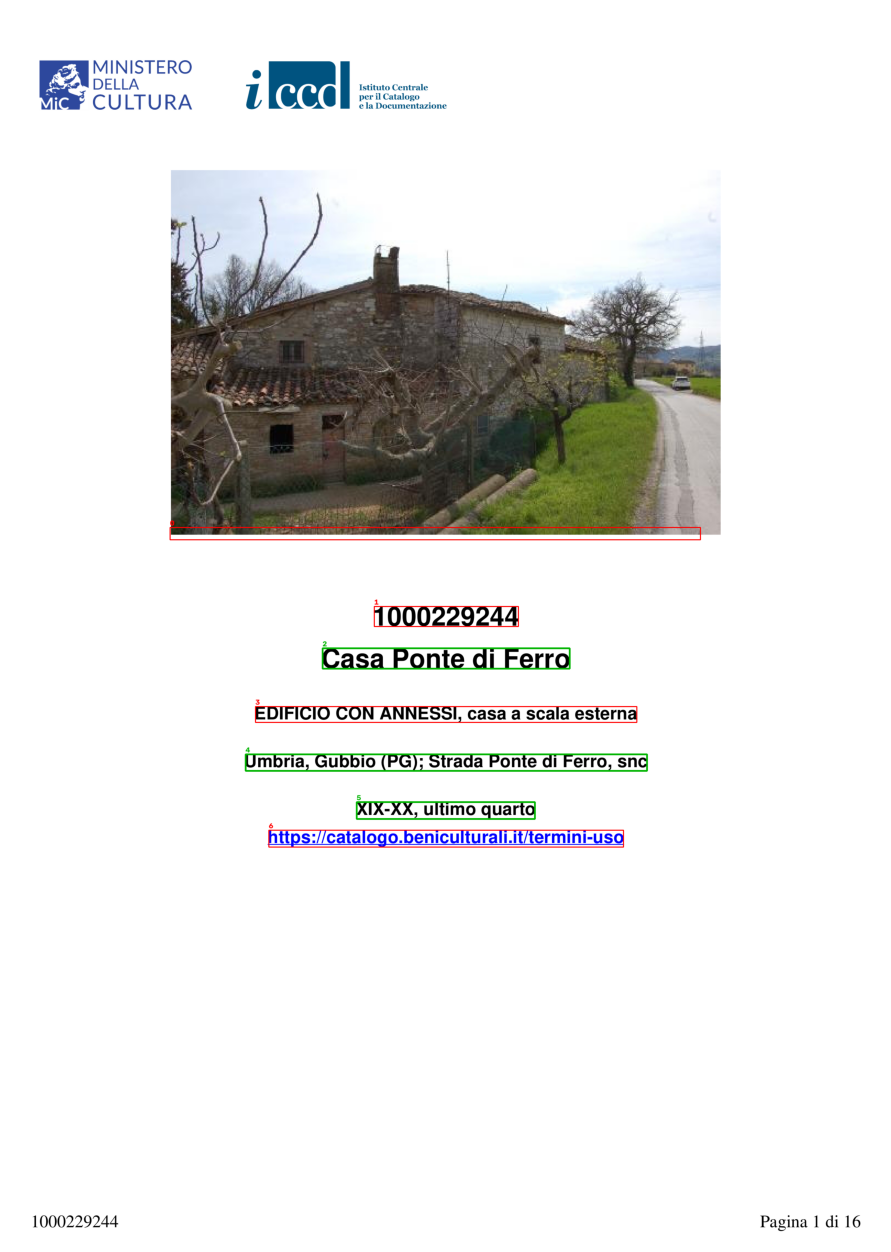

,line_text,confidence,x,y,width,height
0,| - Al iili > 35 A A,46.5,455,1473,1509,35
1,1000229244,96.9,1036,1698,410,57
2,Casa Ponte di Ferro,96.3,889,1817,703,58
3,"EDIFICIO CON ANNESSI, casa a scala esterna",96.5,698,1983,1085,45
4,"Umbria, Gubbio (PG); Strada Ponte di Ferro, snc",96.4,670,2119,1142,47
5,"XIX-XX, ultimo quarto",94.5,986,2255,507,48
6,https://catalogo.beniculturali.it/termini-uso,83.7,736,2335,1009,48


,id,titolo,indirizzo,secolo,linee_rilevate
0,0092caaa-f4cc-4c17-8bc5-e20cbe059637,Casa Ponte di Ferro,"Umbria, Gubbio (PG); Strada Ponte di Ferro, snc","XIX-XX, ultimo quarto",7


In [11]:
def inspect_png(image_path):
    image_path = Path(image_path)
    lines, image = ocr_lines(image_path)
    annotated = image.copy()

    for index, row in enumerate(lines):
        x, y = row['x'], row['y']
        width, height = row['width'], row['height']
        selected = index in {2, 4, 5}
        color = (0, 180, 0) if selected else (0, 0, 255)
        thickness = 4 if selected else 2

        cv2.rectangle(
            annotated, (x, y), (x + width, y + height), color, thickness
        )
        cv2.putText(
            annotated, str(index), (x, max(20, y - 5)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2
        )

    plt.figure(figsize=(12, 16))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    display(pd.DataFrame(lines))
    display(pd.DataFrame([parse_fields(lines, image_path)]))


inspect_png(sample_path)

## 7. Process every PNG and write one JSON file

In [12]:
records = []
warnings = []

for row in tqdm(
    items.itertuples(index=False),
    total=len(items)
):
    if row.path is None:
        warnings.append({
            "id": row.manifest_id,
            "linee_rilevate": 0,
            "warning": "PNG missing",
        })
        continue

    try:
        lines, _ = ocr_lines(row.path)

        record = parse_fields(
            lines,
            row.path
        )

        records.append(record)

        if record["linee_rilevate"] not in (6, 7):
            warnings.append({
                "id": record["id"],
                "linee_rilevate": (
                    record["linee_rilevate"]
                ),
                "warning": (
                    "Unexpected number of OCR lines; "
                    "fields were set to null"
                ),
            })

    except Exception as exc:
        warnings.append({
            "id": row.manifest_id,
            "linee_rilevate": 0,
            "warning": repr(exc),
        })


with OUTPUT_PATH.open(
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        records,
        file,
        ensure_ascii=False,
        indent=2
    )


results_table = pd.DataFrame(records)

print(f"JSON records written: {len(records)}")
print(f"Warnings: {len(warnings)}")
print(f"Output: {OUTPUT_PATH.resolve()}")

display(results_table)

if warnings:
    display(pd.DataFrame(warnings))

  0%|          | 0/438 [00:00<?, ?it/s]

JSON records written: 438
Warnings: 235
Output: /mnt/c/Users/gazza/Documents/DOTDOTDOT - summer/Maps_Rurale_3/foto_modelli/iccd_dati.json


,id,titolo,indirizzo,secolo,linee_rilevate
0,0092caaa-f4cc-4c17-8bc5-e20cbe059637,Casa Ponte di Ferro,"Umbria, Gubbio (PG); Strada Ponte di Ferro, snc","XIX-XX, ultimo quarto",7
1,018a4cb2-a88f-4740-92f0-7cc61a152e51,"EDIFICIO CON ANNESSI, casale","Lombardia, Sant'Omobono Terme (BG); Via San Mi...",NaN,5
2,025184ae-5f48-4929-b70b-116342403adb,NaN,NaN,NaN,9
3,029729ca-8660-4a6b-83a0-d516f223595c,Cascina Uggeri,"Lombardia, Secugnago (LO); Cascina Uggeri, 7","XV-XV, prima meta",7
4,029c2f6d-739c-42ec-a7b3-7b6849fae1f8,NaN,NaN,NaN,4
...,...,...,...,...,...
433,fd3dd90e-ad4d-4d7d-b012-721758fedb1b,"EDIFICIO SINGOLO, casa rurale di montagna","Valle d'Aosta, Valgrisenche (AO); Frazione La ...","XX-XX, ante",6
434,fe9285e7-cbcd-48be-82bc-86bd4b5d17cb,Case Giaculu,"Liguria, Sassello (SV); Via Dano",XX-XX; 1933 ante-1933 ante,7
435,feb5a135-f998-4b72-8d9d-0b9b74a107c3,"EDIFICIO CON ANNESSI, casale","Marche, Fano (PU); Strada Nazionale Adriatica ...","XIX-XIX, inizio/ fine",6
436,ff450bbe-79a7-46ab-b105-4a4ece01a3de,"EDIFICIO SINGOLO, casa alpina","Piemonte, Cesana Torinese (TO); Frazione Champ...",XVII-XXI,6


,id,linee_rilevate,warning
0,018a4cb2-a88f-4740-92f0-7cc61a152e51,5,Unexpected number of OCR lines; fields were se...
1,025184ae-5f48-4929-b70b-116342403adb,9,Unexpected number of OCR lines; fields were se...
2,029c2f6d-739c-42ec-a7b3-7b6849fae1f8,4,Unexpected number of OCR lines; fields were se...
3,02bb044c-8347-4335-8e1d-5d2f3844ded8,5,Unexpected number of OCR lines; fields were se...
4,02f71bb3-78c0-46ba-83e2-9a25cfca315f,5,Unexpected number of OCR lines; fields were se...
...,...,...,...
230,f43b5b6c-61ae-4a5e-b4b8-ff9760f3999b,5,Unexpected number of OCR lines; fields were se...
231,f5681d7f-2186-40ed-96ab-4499163c1611,5,Unexpected number of OCR lines; fields were se...
232,f5892b7c-c1a0-47ec-b146-a039c9c6ee88,8,Unexpected number of OCR lines; fields were se...
233,f80c8119-bb2e-4093-b925-8f7d61ca26a8,5,Unexpected number of OCR lines; fields were se...


## JSON format

The generated `iccd_dati.json` has this structure:

```json
[
  {
    "id": "uuid-from-png-filename",
    "titolo": "Casa Ponte di Ferro",
    "indirizzo": "Umbria, Gubbio (PG); Strada Ponte di Ferro, snc",
    "secolo": "XIX-XX, ultimo quarto"
  }
]
```

If a required OCR row is absent, its value is written as JSON `null`, preserving the four-field schema.